**Step 1**
Importing the data, reading and storing the text files. Using two lists to store the positive and negative texts separately.

*Note: Code below developed with guidance from the Term-Weighting Lab:*
https://colab.research.google.com/drive/1kaMjf5FJ_jOIfR4_Ut4nrghmyqK26a5i?usp=sharing

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

# reading in the review files from folder directory
def readTexts(folderPath):
  texts = []
  for filename in os.listdir(folderPath):
    filePath = os.path.join(folderPath, filename)
    with open(filePath, 'r') as file:
      text = file.read()
      texts.append(text)
  return texts

# storing 2000 positive and 2000 negative reviews in a list structure
posTexts = readTexts('/content/drive/My Drive/Colab Notebooks/data/pos')
negTexts = readTexts('/content/drive/My Drive/Colab Notebooks/data/neg')

print(posTexts[6])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Alan Curtis has a loud, violent sounding argument with his wife, slams out of his apartment, has a night of drinking with a mysterious lady with a large hat in a bar (run by Andrew Tombes, in a nice villainous part for a change), and returns to find his wife dead and the police, led by Thomas Gomez waiting for him. His attempts to prove his alibi - that he was with that mysterious lady - fall because everyone that he can think of (Tombes, Elisha Cook) claims there was never any such person. He ends up with no alibi, although his secretary (who secretly loves him) Ellen Raines believes him. Convicted after a trial, he is awaiting his death sentence. Raines starts going out after the truth, discovering that Gomez has some doubts of his own. She also finds an ally in a friend of Curtis, Franchot Tone, who was apparently out of town the night of the crime. Will s

**Step 2** Pre-processing the data, inspecting and obtaining insights.
Cleaning the data by removing any unnecessary characters, converting to lowercase, and using NLTK to apply tokenisation to the words.

*Note: Code below developed with guidance from the Tokenisation Lab:*
https://colab.research.google.com/drive/1WJ2HEQtwpq7TsGRyV5E1tO6IFGnCbW9A?usp=sharing

In [2]:
import nltk
import string
from nltk import word_tokenize as wordTokenizer
from nltk.stem import LancasterStemmer, WordNetLemmatizer, PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

def tokenizeText(text, parameter):
  wordList = []
  # removing stopwords using a stoplist provided by NLTK library
  # removing punctuation characters using string.punctuation
  stoplist = set(stopwords.words('english'))
  punctuation = string.punctuation
  # tokenizing words and removing any other punctuation using regex
  tokens = wordTokenizer(text)
  regex = RegexpTokenizer(r'\w+')
  # initializing NLTK stemmer and lemmatizer
  stemmer = PorterStemmer()
  lemma = WordNetLemmatizer()
  # converting all words to lowercase
  words = [w.lower() for w in tokens]

  # looping through the text and checking it is a valid token
  # if so, applying stemming or lemmatization
  # and then appending it to the word list if the processed token is 3 characters or more
  for word in words:
    if word not in stoplist and word not in punctuation and word != "":
      if parameter == "lemma":
        word = lemma.lemmatize(word)
      elif parameter == "stemmer":
        word = regex.tokenize(word)
      word = "".join(word)
      if len(word) < 3:
        continue
      else:
        wordList.append(word)
  return wordList

# test method to check if tokenization performs correctly
# using lemmatization on the entire review corpus
def processTexts(texts):
  processedTexts = []
  for text in texts:
    processed = tokenizeText(text, "lemma")
    processedTexts.append(processed)
  return processedTexts

# checking the output of the above tokenizer code
tokenPosTexts = processTexts(posTexts)
tokenNegTexts = processTexts(negTexts)
print("Length of original review: ", len(posTexts[6]))
print("Tokens: ", posTexts[6])
print("Length of tokenized review: ", len(tokenPosTexts[6]))
print("Tokens: ", tokenPosTexts[6])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Length of original review:  3202
Tokens:  Alan Curtis has a loud, violent sounding argument with his wife, slams out of his apartment, has a night of drinking with a mysterious lady with a large hat in a bar (run by Andrew Tombes, in a nice villainous part for a change), and returns to find his wife dead and the police, led by Thomas Gomez waiting for him. His attempts to prove his alibi - that he was with that mysterious lady - fall because everyone that he can think of (Tombes, Elisha Cook) claims there was never any such person. He ends up with no alibi, although his secretary (who secretly loves him) Ellen Raines believes him. Convicted after a trial, he is awaiting his death sentence. Raines starts going out after the truth, discovering that Gomez has some doubts of his own. She also finds an ally in a friend of Curtis, Franchot Tone, who was apparently out of town the night of the crime. Will she clear Curtis in time? THE PHANTOM LADY is based on a novel by William Irish (the gre

**Step 3** Splitting the data into training, development and test splits using *sklearn*. I used the ratio 60:20:20 respectively and used randomized shuffling as the positive and negative classes have an equal amount of texts, so stratified splitting would not have a significant difference.

In [3]:
import sklearn
import numpy
from sklearn.model_selection import train_test_split

# combining both sets of reviews to create a master list
# this contains the positive reviews set concatenated with the negative reviews set
# creating a master list of labels that corresponds with the master list of review texts
allTexts = posTexts + negTexts
labels = [1] * len(posTexts) + [0] * len(negTexts)

# using NLTK train_test_split to split the master review and label lists
# randomized shuffling with random_state = 5 to ensure that the train, development, and
#   test labels match the labels and the texts up
# the ratio is 60:20:20 respectively
xTrain, xTest, yTrain, yTest = train_test_split(allTexts, labels, test_size = 0.2, random_state = 5)
xTrain, xDev, yTrain, yDev = train_test_split(xTrain, yTrain, test_size = 0.25, random_state = 5)

# checking the sizes of each set to ensure they are as expected
print("Training sizes: ", len(xTrain), len(yTrain), "Development sizes: ", len(xDev), len(yDev), "Test sizes: ", len(xTest), len(yTest))

Training sizes:  2400 2400 Development sizes:  800 800 Test sizes:  800 800


In [4]:
# creating an array that stores the length of each text in a given set
# this will be required later when using frequency normalisation
trainLengths = numpy.array([len(text) for text in xTrain])
devLengths = numpy.array([len(text) for text in xDev])
testLengths = numpy.array([len(text) for text in xTest])

# checking the sizes of each set to ensure they are as expected
print("Training sizes: ", len(xTrain), len(yTrain), "Development sizes: ", len(xDev), len(yDev), "Test sizes: ", len(xTest), len(yTest))
print("Sizes of the first 5 reviews in xTrain: ", testLengths[:5])

Training sizes:  2400 2400 Development sizes:  800 800 Test sizes:  800 800
Sizes of the first 5 reviews in xTrain:  [1765  637 1944 1741 1462]


**Step 4** Feature generation using N-grams and choosing “n” = (1, 2, 3.. ).

In [5]:
import numpy
from collections import Counter
from nltk import ngrams

# using NLTK to generate N-grams with n = any specified value
def getNGrams(text, n):
  allgrams = []
  # splitting the text into tuples with n words in each
  ngramList = ngrams(text.split(), n)
  # appending to all N-grams list
  for gram in ngramList:
    allgrams.append(gram)
  return allgrams

# test method to return the most common N-grams in a text
# using Counter.most_common to count the frequency of each tuple
def getMostCommon(ngramList):
  ngramCounts = Counter(ngramList)
  print(ngramCounts.most_common(5))

# checking the output of the above N-grams code
exampleUnigrams = getNGrams(posTexts[6], 1)
exampleBigrams = getNGrams(posTexts[6], 2)
exampleTrigrams = getNGrams(posTexts[6], 3)

print ("\n5 most common unigrams in positive review 6:")
getMostCommon(exampleUnigrams)
print ("\n5 most common bigrams in positive review 6:")
getMostCommon(exampleBigrams)
print ("\n5 most common trigrams in positive review 6:")
getMostCommon(exampleTrigrams)


5 most common unigrams in positive review 6:
[(('the',), 24), (('a',), 18), (('of',), 16), (('his',), 12), (('in',), 12)]

5 most common bigrams in positive review 6:
[(('in', 'a'), 4), (('of', 'his'), 3), (('that', 'he'), 3), (('of', 'the'), 3), (('until', 'the'), 3)]

5 most common trigrams in positive review 6:
[(('wife', 'of', 'a'), 2), (('Raines', 'and', 'Gomez'), 2), (('Alan', 'Curtis', 'has'), 1), (('Curtis', 'has', 'a'), 1), (('has', 'a', 'loud,'), 1)]


**Step 5** Feature selection, using a combination of lemmatization or stemming and normalization techniques to select the
features to train the classifier on.

In [6]:
# STEMMING
# applying stemming to each text in a corpus
# joining the tokenized words into a list of strings
def stemmingTokenize(texts):
  wordList = []
  for text in texts:
    words = tokenizeText(text, "stemmer")
    wordList.append(' '.join(words))
  return wordList

# LEMMATIZATION
# applying lemmatization to each text in a corpus
# joining the tokenized words into a list of strings
def lemmaTokenize(texts):
  wordList = []
  for text in texts:
    words = tokenizeText(text, "lemma")
    wordList.append(' '.join(words))
  return wordList

In [7]:
# FEATURE SET 1:
#     Trigrams
#     Stemming
#     Frequency Normalisation
# extracting trigrams on stemmed training and test data
# and applying TF-IDF to the feature vector

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# creating the feature set and extracting it
def trigramsFeature(train, dev):
  # applying stemming on the train and development sets
  trainText = stemmingTokenize(train)
  devText = stemmingTokenize(dev)
  # getting the adjective list of each set

  # using CountVectorizer to store the collection of token counts in a matrix
  # this will be the input feature vector for Naive Bayes
  vectorizer = CountVectorizer(ngram_range = (3, 3), max_features = 1000)
  trainVector = vectorizer.fit_transform(trainText).toarray()
  devVector = vectorizer.transform(devText).toarray()
  # applying frequency normalization
  # dividing each token count by the total number of tokens in the text
  # create axis with length 1 using [:, None]
  trainVector = trainVector / (trainLengths * 3)[:, None]
  devVector = devVector / (devLengths * 3)[:, None]

  return trainVector, devVector

In [8]:
# FEATURE SET 2:
#     Bigrams
#     Stemming
#     TF-IDF
# extracting bigrams on stemmed training and test data
# and applying TF-IDF to the feature vector

# implementing TF-IDF to normalize the feature vector
def tfidf(featureVector):
  # calculating term frequency and applying frequency normalization
  # adding a small epsilon value to denominator to reduce zero division error
  totalTerms = numpy.sum(featureVector, axis = 1, keepdims = True)
  tf = featureVector / (totalTerms + 0.000000001)

  # calculating inverse document frequency by taking the logarithm
  #   of the total number of docs divided by the frequency of the term across documents
  # adding 1 to the denominator to prevent zero division errors
  totalDocs = featureVector.shape[0]
  totalDocsWithTerm = numpy.sum(featureVector > 0, axis = 0)
  idf = numpy.log(totalDocs / (totalDocsWithTerm + 1))

  # calculating the TF-IDF matrix by multiplying the TF and IDF
  # this will be the feature vector for Naive Bayes
  tfidfMatrix = tf * idf
  return tfidfMatrix

# creating the feature set and extracting it
def bigramsFeature(train, dev):
  # applying stemming
  trainText = stemmingTokenize(train)
  devText = stemmingTokenize(dev)

  # using CountVectorizer as before
  # but setting ngram_range to 2 to generate bigrams
  # the frequency of these bigram tokens will be counted in the matrix
  vectorizer = CountVectorizer(ngram_range = (2, 2), max_features = 1000)
  trainV = vectorizer.fit_transform(trainText).toarray()
  devV = vectorizer.transform(devText).toarray()
  # applying TF-IDF normalisation
  trainVector = tfidf(trainV)
  devVector = tfidf(devV)

  return trainVector, devVector

In [9]:
# FEATURE SET 3:
#     Bag-of-Words (Term Frequency)
#     Lemmatization
#     TF-IDF
# extracting unigrams on lemmatized training and test data
# and applying TF-IDF to the feature vector

def unigramsFeature(train, dev):
  # applying lemmatization
  trainText = lemmaTokenize(train)
  devText = lemmaTokenize(dev)
  # using CountVectorizer as before, but generating unigrams
  vectorizer = CountVectorizer(ngram_range = (1, 1))
  trainV = vectorizer.fit_transform(trainText).toarray()
  devV = vectorizer.transform(devText).toarray()
  # normalizing using TF-IDF
  trainVector = tfidf(trainV)
  devVector = tfidf(devV)

  return trainVector, devVector

In [10]:
# method to select which feature set to extract and input into Naive Bayes
def extractFeature(xTrain, xTest, feature):
  # FEATURE SET 1 - Frequency Normalisation + Trigrams
  if feature == "trigrams":
    trainVector, devVector = trigramsFeature(xTrain, xDev)
    return trainVector, devVector

  # FEATURE SET 2 - TFIDF + Bigrams
  elif feature == "bigrams":
    trainVector, devVector = bigramsFeature(xTrain, xDev)
    return trainVector, devVector

  # FEATURE SET 3 - TFIDF + Unigrams
  elif feature == "unigrams":
    trainVector, devVector = unigramsFeature(xTrain, xDev)
    return trainVector, devVector

**Step 6** Implementing Naïve Bayes from scratch and evaluating it on each of the three different feature sets I extracted. I will use the development set to perform the evaluation and then select the best of the three features to use on the test set.


In [11]:
# initialising dictionaries and alpha = 1 for Laplace smoothing
logClassPriors = {}
logCondProbs = {}
alpha = 1

# Naive Bayes classifier training process
def fit(xTrain, yTrain, featureVector):
  # storing the total number of unique labels as an integer
  #   and all individual labels in a list (which is just [0, 1])
  totalLabels = len(yTrain)
  classLabels = numpy.unique(yTrain)

  # calculating the total number of instances in the training data that belong to the current class
  # summing up the 'True' values (i.e., the 1s) in classIndex
  for label in classLabels:
    classIndex = (yTrain == label)
    classCount = numpy.sum(classIndex)

    # calculating class priors (probability each feature belongs to a certain class)
    # computing proportion of each class in training set and then taking the logarithm
    logClassPriors[label] = numpy.log((classCount + alpha) / (totalLabels + alpha * len(classLabels)))

    # calculating class conditional probabilities by counting the relative frequencies in the training data
    # Laplace-smoothing with alpha = 1 (add-one smoothing) is used to reduce zero division errors

    # selecting the rows in featureVector that correspond to instances of the current class
    #   and then summing column-wise
    num = featureVector[classIndex, :].sum(axis = 0) + alpha
    den = classCount + alpha * featureVector.shape[1]
    # calculating class conditional probability
    logCondProbs[label] = numpy.log(num/den)

# Naive Bayes classifier predicting process
def predict(xTest):
  predictions = []
  for text in xTest:
    classLikelihoods = {}
    # calculating log likelihood for each class considering
    #     both the prior probability of the class and the likelihood of the input text given the class
    for label in logClassPriors:
        classLikelihoods[label] = (logClassPriors[label] + numpy.sum(logCondProbs[label] * text))

    # predicting the class with the highest log probability in the dictionary
    predict = max(classLikelihoods, key = classLikelihoods.get)
    predictions.append(predict)
  return predictions

Outputting perfomance metrics and displaying a confusion map:

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def evaluateModel(yDev, predictions):
  # using performance metrics from sklearn for evaluation
  # testing on the development set (800 entries)
  accuracy = accuracy_score(yDev, predictions)
  precision = precision_score(yDev, predictions)
  recall = recall_score(yDev, predictions)
  f1 = f1_score(yDev, predictions)
  # initialising confusion matrix
  matrix = confusion_matrix(yDev, predictions)

  # outputting perfomance metric values
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 Score: {f1:.2f}")

  # displaying confusion matrix
  print("Confusion Matrix:")
  print(matrix)
  disp = ConfusionMatrixDisplay(confusion_matrix = matrix)
  disp.plot()

FREQUENCY NORMALIZATION + TRIGRAMS
Actual labels:  [0, 1, 0, 0, 1, 0, 1, 0, 1, 1]
Predicted labels:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Accuracy: 0.49
Precision: 0.49
Recall: 1.00
F1 Score: 0.66
Confusion Matrix:
[[  0 406]
 [  0 394]]


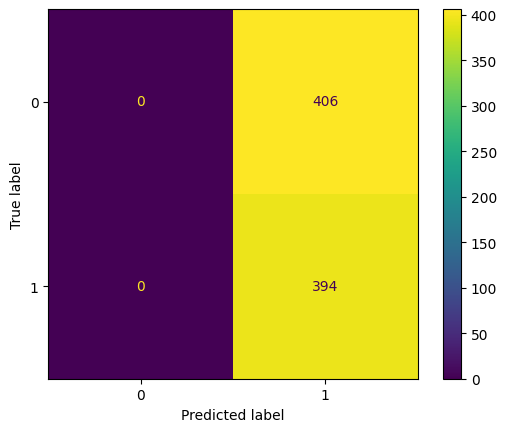

In [13]:
# evaluating FEATURE SET 1 - FREQUENCY NORMALIZATION + TRIGRAMS
# extracting the feature vector and training the Naive Bayes classifier
xTrainVector, xDevVector = extractFeature(xTrain, xDev, "trigrams")
fit(xTrain, yTrain, xTrainVector)
predictions = predict(xDevVector)

print("FREQUENCY NORMALIZATION + TRIGRAMS")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", predictions[:10])
evaluateModel(yDev, predictions)

TFIDF + BIGRAMS
Actual labels:  [0, 1, 0, 0, 1, 0, 1, 0, 1, 1]
Predicted labels:  [1, 1, 0, 1, 1, 0, 1, 1, 1, 1]
Accuracy: 0.70
Precision: 0.69
Recall: 0.70
F1 Score: 0.70
Confusion Matrix:
[[284 122]
 [118 276]]


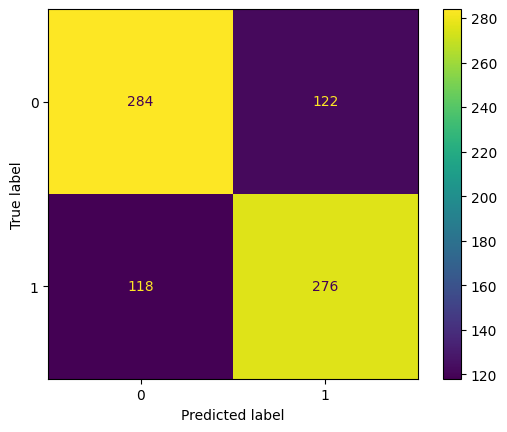

In [14]:
# evaluating FEATURE SET 2 - TFIDF + BIGRAMS
xTrainVector, xDevVector = extractFeature(xTrain, xDev, "bigrams")
fit(xTrain, yTrain, xTrainVector)
predictions = predict(xDevVector)

print("TFIDF + BIGRAMS")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", predictions[:10])
evaluateModel(yDev, predictions)

TFIDF + UNIGRAMS
Actual labels:  [0, 1, 0, 0, 1, 0, 1, 0, 1, 1]
Predicted labels:  [0, 1, 0, 0, 1, 0, 1, 1, 1, 1]
Accuracy: 0.84
Precision: 0.80
Recall: 0.90
F1 Score: 0.85
Confusion Matrix:
[[318  88]
 [ 39 355]]


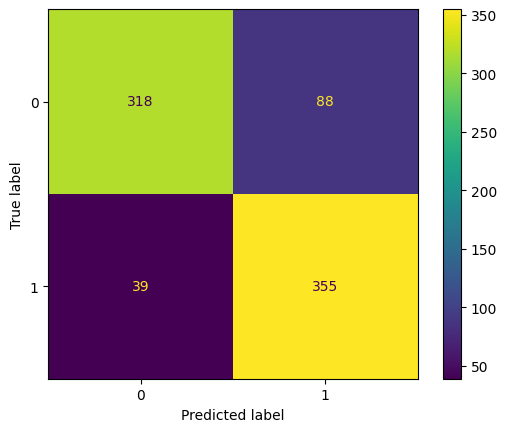

In [15]:
# evaluating FEATURE SET 3 - TFIDF + UNIGRAMS
xTrainVector, xDevVector = extractFeature(xTrain, xDev, "unigrams")
fit(xTrain, yTrain, xTrainVector)
predictions = predict(xDevVector)

print("TFIDF + UNIGRAMS")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", predictions[:10])
evaluateModel(yDev, predictions)

Evaluating highest performing set on the TEST SET
Feature Set 3
Actual labels:  [1, 0, 0, 1, 0, 0, 1, 0, 1, 0]
Predicted labels:  [0, 1, 0, 0, 1, 0, 1, 1, 1, 1]
Accuracy: 0.84
Precision: 0.80
Recall: 0.90
F1 Score: 0.85
Confusion Matrix:
[[318  88]
 [ 39 355]]


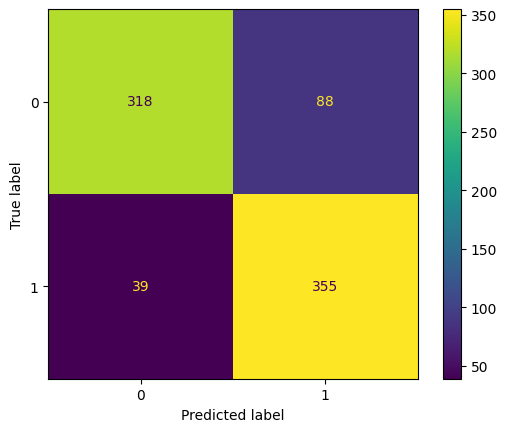

In [16]:
# evaluating highest performing set (FEATURE SET 3) on the TEST SET
xTrainVector, xTestVector = extractFeature(xTrain, xTest, "unigrams")
fit(xTrain, yTrain, xTrainVector)
predictions = predict(xTestVector)

print("Evaluating highest performing set on the TEST SET")
print("Feature Set 3")
print("Actual labels: ", yTest[:10])
print("Predicted labels: ", predictions[:10])
evaluateModel(yDev, predictions)

**Step 7**  Using the Multinomial Naïve Bayes implementation (from https://scikit-learn.org/stable/) on the same three features as above. Comparing this to my classifier from scratch with the same evaluation methods, and evaluating on the test set.

Actual labels:  [1, 0, 0, 1, 0, 0, 1, 0, 1, 0]
Predicted labels:  [0 1 0 0 1 0 1 1 1 1]
Accuracy: 0.84
Precision: 0.81
Recall: 0.89
F1 Score: 0.85
Confusion Matrix:
[[326  80]
 [ 45 349]]


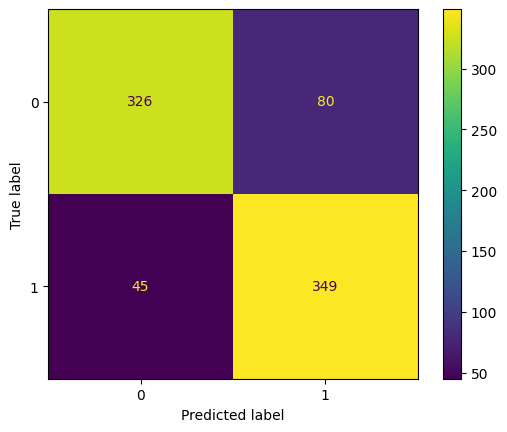

In [17]:
from sklearn.naive_bayes import MultinomialNB

def MNB(xTrain, yTrain, xTest):
  # default parameters: MultinomialNB(alpha = 1.0, class_prior = None, fit_prior = True)
  classifier = MultinomialNB()
  classifier.fit(xTrain, yTrain)
  MNBpredictions = classifier.predict(xTest)
  return MNBpredictions

# extracting feature vectors
xTrainVector, xTestVector = extractFeature(xTrain, xTest, "unigrams")

# training the MultinomialNB classifier and outputting its predictions
MNBpredictions = MNB(xTrainVector, yTrain, xTestVector)
print("Actual labels: ", yTest[:10])
print("Predicted labels: ", MNBpredictions[:10])

# evaluating the model using performance metrics and confusion matrix
evaluateModel(yDev, MNBpredictions)

**Step 8** Implementing Support Vector Machine (SVM) and Logistic Regression (LR) Classification using packages from https://scikit-learn.org/stable/. Evaluating them as before on the development set with each of the three different feature sets I extracted. The datasets are one hot encoded, and the best model will be fine-tuned even further by experimenting with 5 different sets and values of hyperparameters.

In [1]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

def oneHotEncoder(xTrain, xDev):
  # initializing OneHotEncoder from sklearn
  encoder = OneHotEncoder(handle_unknown ='ignore', max_categories = 1000)
  # fit and transform on training labels
  xTrainEncoded = encoder.fit_transform(xTrain).toarray()
  xDevEncoded = encoder.transform(xDev).toarray()
  return xTrainEncoded, xDevEncoded

# training the Logistic Regression classifier and returning its predictions
def LR(xTrainVector, yTrain, xDevVector):
  LRclassifier = LogisticRegression(random_state = 42)
  LRclassifier.fit(xTrainVector, yTrain)
  LRpredictions =  LRclassifier.predict(xDevVector)
  return LRpredictions

# training the Support Vector Machine classifier and returning its predictions
def SVM(xTrainVector, yTrain, xDevVector):
  #SVMClassifier = SVC()
  linearSVC = LinearSVC()
  linearSVC.fit(xTrainVector, yTrain)
  SVMpredictions = linearSVC.predict(xDevVector)
  return SVMpredictions

# extracting feature vectors
xTrainVector, xDevVector = extractFeature(xTrain, xDev, "unigrams")
# one hot encoding the sets
xTrainEncoded, xDevEncoded = oneHotEncoder(xTrainVector, xDevVector)
"""
# training the classifiers
# outputting performance metrics and confusion matrices
LRpredictions = LR(xTrainEncoded, yTrain, xDevEncoded)
print("Logistic Regression results:")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", LRpredictions[:10])
evaluateModel(yDev, LRpredictions)
"""
SVMpredictions = SVM(xTrainEncoded, yTrain, xDevEncoded)
print("SVM results:")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", SVMpredictions[:10])
evaluateModel(yDev, SVMpredictions)

NameError: ignored

**Aside** - Below are code cells containing extended features and other analyses I tried to implement, but did not have enough time to complete.

In [ ]:
"""
# FEATURE 4:
#     Unigrams
#     Lemmatization
#     PPMI
# extracting unigrams with lemmatization
# normalizing with positive pointwise mutual information (PPMI)

def ppmi(featureVector):
  # using the shape of the feature vector to get totals
  #    rows = total number of texts
  #   columns = total number of terms
  totalTexts = featureVector.shape[0]
  totalTerms = featureVector.shape[1]

  # calculating joint probabilities
  probIxJ = featureVector / (totalTexts + 0.000000001)

  # calculating marginal probabilities
  # summing the row (probI) and column (probJ) values
  #   and dividing by the total amount of values
  probI = numpy.sum(featureVector, axis=0) / totalTexts
  probJ = numpy.sum(featureVector, axis=1).reshape(-1, 1) / totalTerms

  # using a small epsilon value of 0.000000001 to prevent zero divison error
  probIxJ[probIxJ == 0] = 0.000000001
  probI[probI == 0] = 0.000000001
  probJ[probJ == 0] = 0.000000001

  # calculating the PPMI matrix
  # taking the base 2 logarithm of the join probability
  #   divided by the marginal probabilities multiplied
  ppmiMatrix = numpy.log2(probIxJ / (probI * probJ))

  # replacing negative values with zero (since PPMI should be non-negative)
  ppmiMatrix[ppmiMatrix < 0] = 0
  return ppmiMatrix

def ppmiFeature(train, dev):
  # applying lemmatization
  trainText = lemmaTokenize(train)
  devText = lemmaTokenize(dev)
  # using CountVectorizer and generating unigrams
  vectorizer = CountVectorizer(ngram_range = (2, 2) , max_features = 1000)
  trainV = vectorizer.fit_transform(trainText).toarray()
  devV = vectorizer.transform(devText).toarray()
  # normalizing using PPMI
  trainVector = ppmi(trainV)
  devVector = ppmi(devV)

  return trainVector, devVector
  """

In [ ]:
"""
  # FEATURE SET 4 - PPMI + Unigrams
  elif feature == "ppmi":
    trainVector, devVector = ppmiFeature(xTrain, xDev)
    return trainVector, devVector
"""

In [ ]:
"""
# evaluating FEATURE SET 4 - PPMI + Unigrams
xTrainVector, xDevVector = extractFeature(xTrain, xDev, "ppmi")

fit(xTrain, yTrain, xTrainVector)
predictions = predict(xDevVector)

print("PPMI + UNIGRAMS")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", predictions[:10])
evaluateModel(yDev, predictions)
"""

In [ ]:
"""
# training the Stochastic Gradient Descent classifier and returning its predictions
def SGD(xTrainVector, yTrainEncoded, xDevVector):
  # initializing classifier and setting logistic regression as the loss function
  SGDclassifier = SGDClassifier(loss='log', random_state=42)
  SGDclassifier.fit(xTrainVector, yTrainEncoded)
  SGDpredictions = SGDclassifier.predict(xDevVector)
  return SGDpredictions
"""
"""
SGDpredictions = SGD(xTrainEncoded, yTrain, xDevEncoded)
print("SGD results:")
print("Actual labels: ", yDev[:10])
print("Predicted labels: ", SGDpredictions[:10])
evaluateModel(yDev, SGDpredictions)
"""